In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_DTL = pd.read_csv("../DTL_frames/landmarks_unnormalised_with_angles.csv")


# Ensure consistent Position order
positions_order = sorted(df_DTL["Position"].unique(), key=lambda x: int(x[1:]))
df_DTL["Position"] = pd.Categorical(df_DTL["Position"], categories=positions_order, ordered=True)

df_DTL

,Frame_Name,Person,Camera_Angle,Frame_Number,Position,NOSE_X,NOSE_Y,NOSE_Z,NOSE_V,LEFT_EYE_INNER_X,...,LEFT_FOOT_INDEX_Z,LEFT_FOOT_INDEX_V,RIGHT_FOOT_INDEX_X,RIGHT_FOOT_INDEX_Y,RIGHT_FOOT_INDEX_Z,RIGHT_FOOT_INDEX_V,shoulder_tilt_deg,hip_tilt_deg,shoulder_rotation_deg,hip_rotation_deg
0,eric_DTL_1_frame0.jpg,eric_DTL_1,DTL,frame0,P1,500.685204,224.357605,-164.420554,0.998422,502.821858,...,252.747572,0.920501,424.945208,614.573546,-337.848553,0.994325,15.339738,3.616193,87.832446,83.582806
1,eric_DTL_1_frame1.jpg,eric_DTL_1,DTL,frame1,P1,500.685342,224.236065,-137.835800,0.998478,502.817045,...,268.564459,0.921419,423.915026,614.529843,-336.818024,0.994507,14.872318,3.314035,88.168022,84.561865
2,eric_DTL_1_frame2.jpg,eric_DTL_1,DTL,frame2,P1,500.685966,224.157304,-150.490638,0.998537,502.819192,...,265.001244,0.921430,423.587043,614.414715,-332.550602,0.994595,11.151093,1.671229,88.154952,84.753724
3,eric_DTL_1_frame3.jpg,eric_DTL_1,DTL,frame3,P1,500.685134,223.511236,-151.848907,0.998601,502.776770,...,257.747495,0.921157,423.087293,614.413829,-358.387437,0.994714,2.660642,0.560818,87.668090,84.490491
4,eric_DTL_1_frame4.jpg,eric_DTL_1,DTL,frame4,P1,500.629103,222.378161,-164.326758,0.998663,502.616570,...,225.974542,0.920982,422.591872,614.499348,-394.855773,0.994804,1.229292,0.400833,86.227771,83.821605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,tom_DTL_2_frame46.jpg,tom_DTL_2,DTL,frame46,P10,1042.952042,283.606492,356.901884,0.998629,1047.890282,...,-36.103806,0.765470,956.538563,960.712166,-18.632292,0.963517,28.239687,15.386374,42.577308,3.614665
401,tom_DTL_2_frame47.jpg,tom_DTL_2,DTL,frame47,P10,1033.904572,272.849858,306.425972,0.998754,1041.447258,...,-52.880244,0.777543,948.990726,957.579131,28.332757,0.954415,25.057718,14.180205,58.605052,37.018420
402,tom_DTL_2_frame48.jpg,tom_DTL_2,DTL,frame48,P10,1036.118202,272.935249,374.416952,0.998870,1042.329140,...,-49.272945,0.788076,947.058105,955.428300,38.686305,0.947865,23.589274,13.482080,54.750172,33.445543
403,tom_DTL_2_frame49.jpg,tom_DTL_2,DTL,frame49,P10,1036.235962,278.292693,411.575060,0.998975,1040.064812,...,-11.685797,0.797416,947.557640,956.401813,10.815871,0.944726,21.048784,13.229790,51.353984,10.318760


In [ ]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# --- Helper angle function ---
def calculate_angle(a, b, c):
    """Calculates the angle between three points.

    Args:
        a: The first point as a list or tuple [x, y].
        b: The second (vertex) point as a list or tuple [x, y].
        c: The third point as a list or tuple [x, y].

    Returns:
        The angle in degrees.
    """
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)
    
    radians = np.arctan2(c[1] - b[1], c[0] - b[0]) - np.arctan2(a[1] - b[1], a[0] - b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    
    if angle > 180.0:
        angle = 360 - angle
        
    return angle


# --- Forward Tilt ---
def compute_forward_tilt(row):
    ls = np.array([row["LEFT_SHOULDER_X"], row["LEFT_SHOULDER_Y"]])
    rs = np.array([row["RIGHT_SHOULDER_X"], row["RIGHT_SHOULDER_Y"]])
    lh = np.array([row["LEFT_HIP_X"], row["LEFT_HIP_Y"]])
    rh = np.array([row["RIGHT_HIP_X"], row["RIGHT_HIP_Y"]])
    mid_shoulder = (ls + rs) / 2
    mid_hip = (lh + rh) / 2

    # Create vertical reference
    vertical_ref = (mid_hip[0], 0)
    return calculate_angle(mid_shoulder, mid_hip, vertical_ref)


# --- Knee Bend (per leg) ---
def compute_knee_bend(row, side="LEFT"):
    hip = (row[f"{side}_HIP_X"], row[f"{side}_HIP_Y"])
    knee = (row[f"{side}_KNEE_X"], row[f"{side}_KNEE_Y"])
    ankle = (row[f"{side}_ANKLE_X"], row[f"{side}_ANKLE_Y"])
    return calculate_angle(hip, knee, ankle)


# --- Hand Position (horizontal offset wrists - hips) ---
def compute_hand_position(row):
    lw, rw = np.array([row["LEFT_WRIST_X"], row["LEFT_WRIST_Y"]]), np.array([row["RIGHT_WRIST_X"], row["RIGHT_WRIST_Y"]])
    lh, rh = np.array([row["LEFT_HIP_X"], row["LEFT_HIP_Y"]]), np.array([row["RIGHT_HIP_X"], row["RIGHT_HIP_Y"]])
    mid_wrist_x = (lw[0] + rw[0]) / 2
    mid_hip_x = (lh[0] + rh[0]) / 2
    return mid_wrist_x - mid_hip_x  # negative = hands ahead


# --- Apply to all frames ---
df_DTL["forward_tilt_deg"] = df_DTL.apply(compute_forward_tilt, axis=1)
df_DTL["left_knee_bend_deg"] = df_DTL.apply(lambda r: compute_knee_bend(r, "LEFT"), axis=1)
df_DTL["right_knee_bend_deg"] = df_DTL.apply(lambda r: compute_knee_bend(r, "RIGHT"), axis=1)
df_DTL["knee_bend_mean_deg"] = df_DTL[["left_knee_bend_deg", "right_knee_bend_deg"]].mean(axis=1)
df_DTL["hand_position_xdiff"] = df_DTL.apply(compute_hand_position, axis=1)

# --- Compute mean and std deviation by Position ---
angle_summary = (
    df_DTL.groupby("Position")[["forward_tilt_deg", "knee_bend_mean_deg", "hand_position_xdiff"]]
    .agg(["mean", "std"])
    .reset_index()
)

angle_summary.columns = ["Position",
                         "forward_tilt_mean", "forward_tilt_std",
                         "knee_bend_mean", "knee_bend_std",
                         "hand_pos_mean", "hand_pos_std"]

print(angle_summary)

  Position  forward_tilt_mean  forward_tilt_std  knee_bend_mean  \
0       P1          34.227513          5.225493      157.923937   
1       P2          31.706497          4.181243      156.697249   
2       P3          30.260698          5.221362      155.255068   
3       P4          29.120636          4.983437      151.909706   
4       P5          30.139738          5.446010      147.520185   
5       P6          31.670827          4.682535      151.482319   
6       P7          29.439220          5.190018      156.634557   
7       P8          29.909508          4.796196      161.341996   
8       P9          26.356029          4.411809      164.300902   
9      P10          23.049288          3.963039      172.531026   

   knee_bend_std  hand_pos_mean  hand_pos_std  
0       5.229965     101.626989     34.791581  
1       3.714490      76.086130     36.646858  
2       5.061419      31.202797     33.773601  
3       6.729133      -3.980596     15.263698  
4       7.423650      

C:\Users\cryst\AppData\Local\Temp\ipykernel_43588\1985098850.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_DTL.groupby("Position")[["forward_tilt_deg", "knee_bend_mean_deg", "hand_position_xdiff"]]


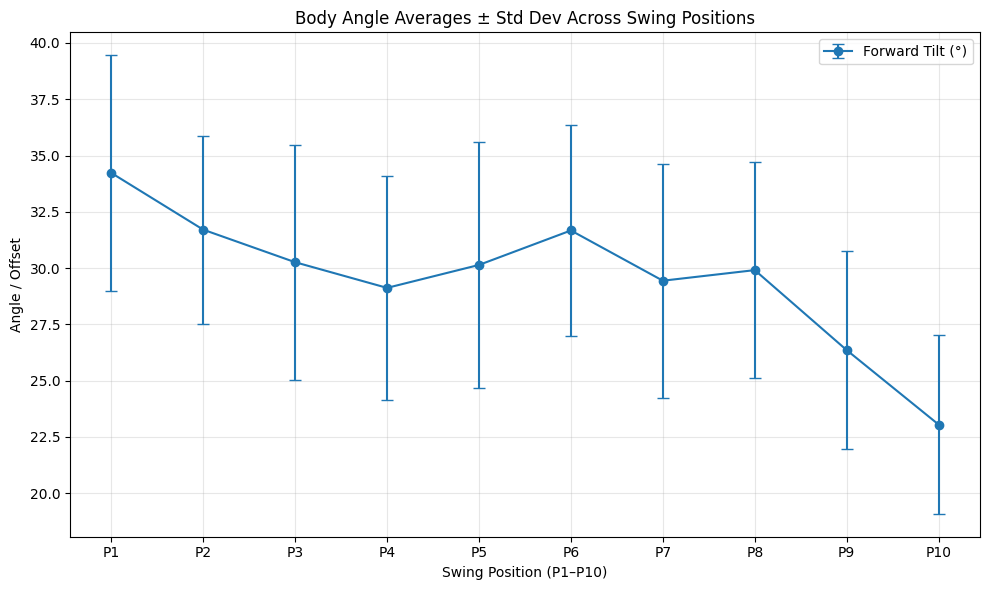

In [6]:
plt.figure(figsize=(10,6))

# Forward tilt
plt.errorbar(angle_summary["Position"], angle_summary["forward_tilt_mean"], 
             yerr=angle_summary["forward_tilt_std"], fmt='-o', capsize=4, label="Forward Tilt (°)")

# Knee bend
# plt.errorbar(angle_summary["Position"], angle_summary["knee_bend_mean"], 
#              yerr=angle_summary["knee_bend_std"], fmt='-o', capsize=4, label="Knee Bend (°)")

# Hand position
# plt.errorbar(angle_summary["Position"], angle_summary["hand_pos_mean"], 
#              yerr=angle_summary["hand_pos_std"], fmt='-o', capsize=4, label="Hand Position (x-diff)")

plt.title("Body Angle Averages ± Std Dev Across Swing Positions")
plt.xlabel("Swing Position (P1–P10)")
plt.ylabel("Angle / Offset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()